In [1]:
import numpy as np
import matplotlib.pyplot
from utils import *
from scipy.sparse.linalg import expm
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt
from ionq_circuit_utils import *

In [21]:
def aams(phi_0, phi_1, theta):
    return np.array([[np.cos(theta/2), 0, 0, -1j * np.exp(-1j * (phi_0 + phi_1)) * np.sin(theta/2)],
                     [0, np.cos(theta/2), -1j * np.exp(-1j * (phi_0 - phi_1)) * np.sin(theta/2), 0],
                     [0, -1j * np.exp(1j * (phi_0 - phi_1)) * np.sin(theta/2), np.cos(theta/2), 0],
                     [-1j * np.exp(1j * (phi_0 + phi_1)) * np.sin(theta/2), 0, 0, np.cos(theta/2)]])

def aams_2(phi_0, phi_1, theta):
    return expm(-1j * (theta / 2) * tensor([np.cos(phi_0) * PAULI_X + np.sin(phi_0) * PAULI_Y, np.cos(phi_1) * PAULI_X + np.sin(phi_1) * PAULI_Y])).toarray()

In [12]:
t = np.random.rand()
phi = np.random.rand()
phi_2 = np.random.rand()
a = expm(1j * (phi_2 / 2) * PAULI_Z) @ expm(-1j * (t / 2) * (np.cos(phi) * PAULI_X + np.sin(phi) * PAULI_Y)) @ expm(-1j * (phi_2 / 2) * PAULI_Z)
b = expm(-1j * (t / 2) * (np.cos(phi - phi_2) * PAULI_X + np.sin(phi - phi_2) * PAULI_Y))

In [27]:
t1, t2 = np.random.rand(2)
phi_0, phi_1 = np.random.rand(2)
theta = np.random.rand()

In [32]:
first = expm(1j * (t1 / 2) * tensor([IDENTITY, PAULI_Z])).toarray() @ aams(phi_0, phi_1, theta) @ expm(-1j * (t1 / 2) * tensor([IDENTITY, PAULI_Z])).toarray()

second = aams(phi_0, phi_1 - t1, theta)

print(np.linalg.norm(first - second))

1.6184142622847344e-16


In [31]:
np.abs(np.trace(first @ np.conj(second.T))) / 4

1.0

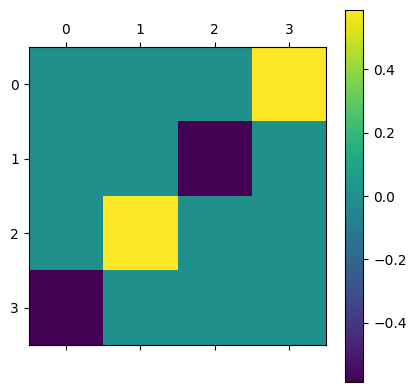

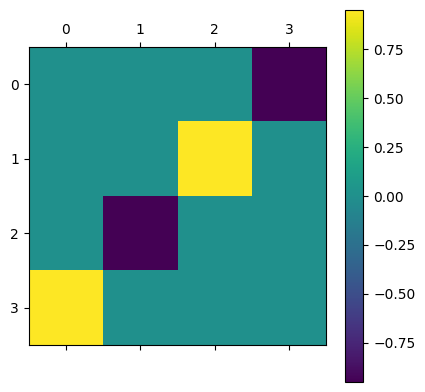

In [87]:
plt.matshow(first.real)
plt.colorbar()
plt.matshow(second.real)
plt.colorbar()
plt.show()

In [10]:
aams(0, -np.pi/2, theta=np.pi)

array([[ 6.123234e-17+0.000000e+00j,  0.000000e+00+0.000000e+00j,
         0.000000e+00+0.000000e+00j,  1.000000e+00-6.123234e-17j],
       [ 0.000000e+00+0.000000e+00j,  6.123234e-17+0.000000e+00j,
        -1.000000e+00-6.123234e-17j,  0.000000e+00+0.000000e+00j],
       [ 0.000000e+00+0.000000e+00j,  1.000000e+00-6.123234e-17j,
         6.123234e-17+0.000000e+00j,  0.000000e+00+0.000000e+00j],
       [-1.000000e+00-6.123234e-17j,  0.000000e+00+0.000000e+00j,
         0.000000e+00+0.000000e+00j,  6.123234e-17+0.000000e+00j]])

In [25]:
asdf = aams(0,-np.pi/2,np.pi)
asdf2 = aams_2(0,-np.pi/2, np.pi)

In [26]:
asdf

array([[ 6.123234e-17+0.000000e+00j,  0.000000e+00+0.000000e+00j,
         0.000000e+00+0.000000e+00j,  1.000000e+00-6.123234e-17j],
       [ 0.000000e+00+0.000000e+00j,  6.123234e-17+0.000000e+00j,
        -1.000000e+00-6.123234e-17j,  0.000000e+00+0.000000e+00j],
       [ 0.000000e+00+0.000000e+00j,  1.000000e+00-6.123234e-17j,
         6.123234e-17+0.000000e+00j,  0.000000e+00+0.000000e+00j],
       [-1.000000e+00-6.123234e-17j,  0.000000e+00+0.000000e+00j,
         0.000000e+00+0.000000e+00j,  6.123234e-17+0.000000e+00j]])

In [16]:
np.linalg.norm(asdf - asdf2)

1.2246467991473532e-16

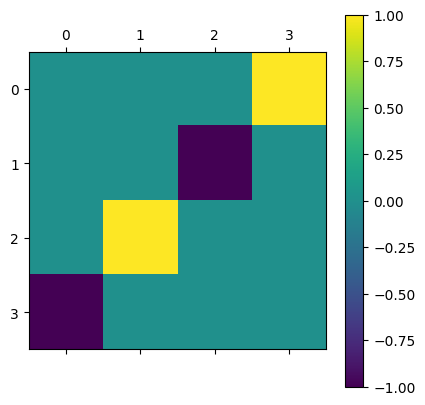

2.1211504774498138e-16

In [27]:
rot_angle = np.pi

phi_0 = 0#np.random.rand()
phi_1 = 0#np.random.rand()
theta = np.pi#np.random.rand()

asdf = aams(phi_0, phi_1, theta) @ tensor([IDENTITY, expm(-1j * (rot_angle / 2) * PAULI_Z)])

plt.matshow(asdf.real)
plt.colorbar()
plt.show()

asdf2 = aams(phi_0, phi_1 - rot_angle/2, theta)

np.linalg.norm(asdf - asdf2)

In [18]:
phi_0, phi_1 - rot_angle, theta

(0, -3.141592653589793, 3.141592653589793)

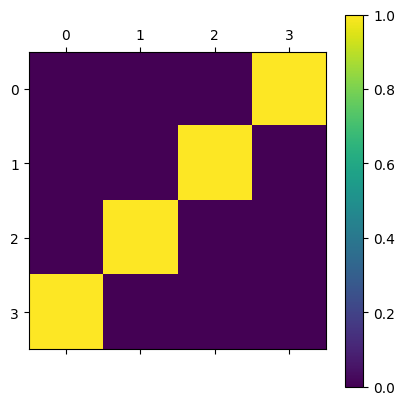

In [8]:
plt.matshow(asdf2.imag)
plt.colorbar()
plt.show()

$$
    \frac{1}{2i} [Z_1 X_3, Z_2 Z_3] = Z_1 Z_2 Y_3
$$

In [2]:
Z1Z2Y3 = tensor([PAULI_Z, PAULI_Z, PAULI_Y])

In [5]:
Z1X3 = tensor([PAULI_Z, IDENTITY, PAULI_X])
Z2Z3 = tensor([IDENTITY, PAULI_Z, PAULI_Z])

In [8]:
norm((Z1X3 @ Z2Z3 - Z2Z3 @ Z1X3) / (2j) + Z1Z2Y3)

0.0

Refer to Lemma 7 in https://arxiv.org/abs/2003.06886.
Decomposing into products of 2-local Pauli's, we have

$$
    e^{-i \delta Z_1 Z_2 Y_3} \approx e^{-i \sqrt{\delta/2}} Z_1 X_3 e^{i \sqrt{\delta/2} Z_2 Z_3} e^{i\sqrt{\delta/2} Z_1 X_3} e^{-i\sqrt{\delta/2} Z_2 Z_3}.
$$

In [98]:
np.arctan(1)

0.7853981633974483

In [ ]:
t

In [101]:
np.arctan2(1, 0)

1.5707963267948966

In [103]:
t = 0
assert 0 <= t <= np.pi/2
print(1 / (np.sin(t) + np.cos(t)))
t1 = np.arctan2(1 / (np.sin(t) + np.cos(t)), np.sqrt(np.sin(2 * t)) / (np.sin(t) + np.cos(t)))* 2
t2 = np.arctan2(np.cos(t) - np.sin(t), -np.sqrt(np.sin(2 * t))) * 2

print(f"t1 = {t1}")
print(f"t2 = {t2}")

h1 = Z1X3
h2 = Z2Z3
H = (h1 @ h2 - h2 @ h1) / 2j

U = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)

# U = expm(-1j * np.sqrt(t/2) * h1) @ expm(1j * np.sqrt(t/2) * h2) @ expm(1j * np.sqrt(t/2) * h1) @ expm(-1j * np.sqrt(t/2) * h2)

R_ZZY = expm(1j * t * H)
print(norm(U - R_ZZY))

1.0
t1 = 3.141592653589793
t2 = 3.141592653589793
1.499680378916329e-15


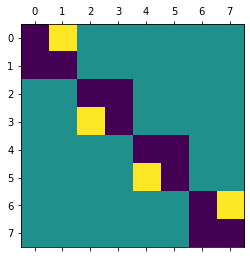

In [97]:
plt.matshow(U.toarray().real)
plt.show()

In [82]:
np.arctan2(1, 0)

1.5707963267948966

In [121]:
t_vals = np.linspace(0, np.pi / 2, 50)
error = []

for t in t_vals:
    t1 = np.arctan2(1 / (np.sin(t) + np.cos(t)), -np.sqrt(np.sin(2 * t)) / (np.sin(t) + np.cos(t))) /2
    t2 = np.arctan2(np.cos(t) - np.sin(t), +np.sqrt(np.sin(2 * t))) /2

    # print(f"t1 = {t1}")
    # print(f"t2 = {t2}")

    # Z1X3 = 
    # Z2Z3 = tensor([IDENTITY, PAULI_Z, PAULI_Z])
    h1 = tensor([PAULI_Z, PAULI_X, IDENTITY])
    h2 = tensor([IDENTITY, PAULI_Y, PAULI_Z])
    H = (h1 @ h2 - h2 @ h1) / 2j

    # U = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)

    U = expm(-1j * np.sqrt(t/2) * h1) @ expm(1j * np.sqrt(t/2) * h2) @ expm(1j * np.sqrt(t/2) * h1) @ expm(-1j * np.sqrt(t/2) * h2)

    R_ZZY = expm(1j * t * H)
    error.append(norm(U - R_ZZY))



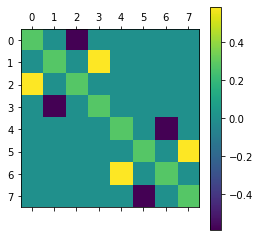

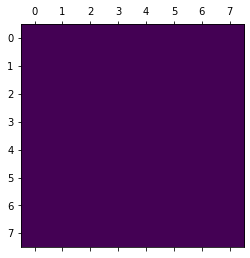

In [122]:
plt.matshow(U.toarray().real)
plt.colorbar()
plt.show()

plt.matshow(R_ZZY.toarray().real)
plt.show()

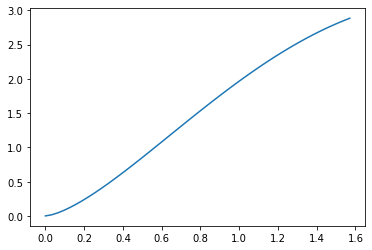

In [123]:
plt.plot(t_vals, error)
plt.show()

In [65]:
0 <= t <= np.pi / 2

True

In [59]:
# U = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)

U = expm(-1j * np.sqrt(t/2) * h1) @ expm(1j * np.sqrt(t/2) * h2) @ expm(1j * np.sqrt(t/2) * h1) @ expm(-1j * np.sqrt(t/2) * h2)

In [63]:
R_ZZY = expm(-1j * t * Z1Z2Y3)

In [64]:
norm(U - R_ZZY)

0.08692105665165789

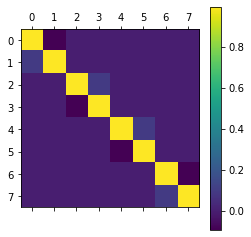

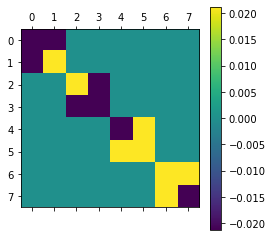

In [60]:
plt.matshow(U.toarray().real)
plt.colorbar()
plt.show()
plt.matshow(U.toarray().imag)
plt.colorbar()
plt.show()

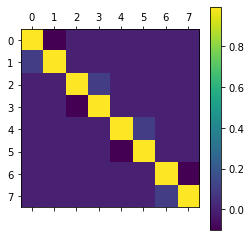

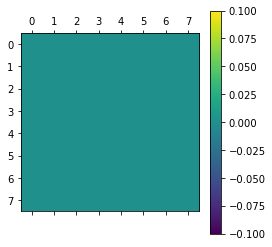

In [61]:

plt.matshow(R_ZZY.toarray().real)
plt.colorbar()
plt.show()
plt.matshow(R_ZZY.toarray().imag)
plt.colorbar()
plt.show()

In [4]:
S_Y = sum_y(3).toarray()

In [32]:
V = np.zeros((2**3, 3))
for i in range(2 ** 3):
    V[i,bin(i).count("1") % 3] += 1
for i in range(3):
    V[:,i] /= np.sqrt(np.sum(V[:,i]))

In [34]:
S = V.T @ S_Y @ V

In [39]:
for i in range(3):
    for j in range(3):
        if np.real(S[i,j] * 1j) > 0:
            print(f"({i},{j})")

(0,1)
(1,2)
(2,0)


In [10]:
import numpy as np
from scipy.sparse.linalg import expm_multiply
from utils import *
from os.path import join
from time import time
start = time()
DATA_DIR = "data"

C6 = 862690 * 2 * np.pi # Rydberg interaction constant (MHz⋅μm^6)
R = 4.0 # Lattice scale / μm
Ω_0 = 0.25 # (Global) Rabi frequency (MHz)
ts = 4.0 # Simulation time (μs)

CURR_DIR = DATA_DIR
check_and_make_dir(CURR_DIR)

print("Running simulation of ODE/PDE solver on Rydberg atoms.")

# number of qubits
n = 2
# number of chains
d = 2
# number of grid points in along one axis
N = (n+1)
# size of interval
L = 1
# mesh spacing
h = L/(N-1)
# parameters for discretized delta
m = 1
omega = (m * h) ** (1/2)
q = np.linspace(0, L, N)
num_time_points = 64
times = np.linspace(0, ts, num_time_points)
print(f"Simulating n={n} atoms on each chain.")
print(f"Mesh resolution: h={h: 0.3f}")

x0_tmp, x1_tmp = np.meshgrid(np.linspace(0, L, N), np.linspace(0, L, N), indexing='ij')
X = np.stack([x0_tmp, x1_tmp], axis=-1)

# Initial condition in the codeword subspace
X_0 = np.array([0.3, 0.7])
psi_0_subspace = delta_multivar(X - X_0, omega)
psi_0_subspace /= np.linalg.norm(psi_0_subspace)

x0 = np.linspace(0, L, N)
x1 = np.linspace(0, L, N)

x0_midpoints = np.zeros(N-1)
x1_midpoints = np.zeros(N-1)
for i in range(N-1):
    x0_midpoints[i] = (x0[i] + x0[i+1]) / 2
    x1_midpoints[i] = (x1[i] + x1[i+1]) / 2

# Functions in the ODE problem
F0 = 0.5 * x0_midpoints + 0.2 * x1_midpoints
F1 = - 0.1 * x0_midpoints - 0.5 * x1_midpoints

# Rydberg atoms
chain_locations = np.zeros(n)
for k in range(n):
    chain_locations[k] = R * (n - 1 - k)

qubit_locations = np.concatenate([chain_locations, chain_locations])

detuning = np.zeros(n)
for i in range(n):
    if i % 2 == 0:
        for j in range(int((n-i)/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i + (2 * j + 1)]) ** 6
        for j in range(int(i/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i - (2 * (j + 1))]) ** 6
    else:
        for j in range(int((n-1-i)/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i + (2 * (j + 1))]) ** 6
        for j in range(int((i+1)/2)):
            detuning[i] += C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[i - (2 * j + 1)]) ** 6

# Ignore interactions between two chains
V = np.zeros((d * n, d * n))
for i in range(n):
    for j in range(i):
        V[i,j] = C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[j]) ** 6
        V[i+n,j+n] = C6 / np.linalg.norm(qubit_locations[i] - qubit_locations[j]) ** 6

delta = np.concatenate([detuning, detuning])

alternating_sign = np.array([(-1)**i for i in range(n)])
local_rabi_freq_1 = F0 * alternating_sign
local_rabi_freq_2 = F1 * alternating_sign
rabi_freq = Ω_0 * np.concatenate([local_rabi_freq_1, local_rabi_freq_2]) / h
H = driving_term(d * n, rabi_freq) - sum_delta_n(d * n, delta) + sum_V_nn(d * n, V)

# Initialize the full psi_0
psi_0 = np.zeros(2 ** (d * n))
bitstring_1 = [k % 2 for k in range(n)]
for i in range(n+1):

    bitstring_2 = [k % 2 for k in range(n)]
    for j in range(n+1):

        full_bitstring = np.concatenate([bitstring_1, bitstring_2])
        psi_0[bitstring_to_int(full_bitstring)] = psi_0_subspace[i,j]

        if j < n:
            bitstring_2[j] = 1 - bitstring_2[j]

    if i < n:
        bitstring_1[i] = 1 - bitstring_1[i]

psi_0 /= np.linalg.norm(psi_0)



Running simulation of ODE/PDE solver on Rydberg atoms.
Simulating n=2 atoms on each chain.
Mesh resolution: h= 0.500


In [4]:
import matplotlib.pyplot as plt

In [9]:
V

array([[      0.        ,       0.        ,       0.        ,
              0.        ],
       [5420441.13265076,       0.        ,       0.        ,
              0.        ],
       [      0.        ,       0.        ,       0.        ,
              0.        ],
       [      0.        ,       0.        , 5420441.13265076,
              0.        ]])

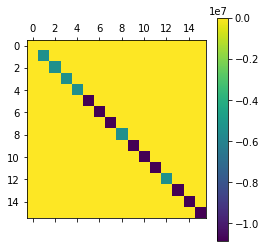

In [8]:
plt.matshow(H.toarray().real)

plt.colorbar()
plt.show()

In [ ]:
# faster but should require more memory to store state vector for all time points
psi = expm_multiply(-1j * H, psi_0, start=0, stop=ts, num=num_time_points)

psi_subspace = np.zeros((num_time_points,n+1,n+1))
for i in range(n+1):

    bitstring_2 = [k % 2 for k in range(n)]
    for j in range(n+1):

        full_bitstring = np.concatenate([bitstring_1, bitstring_2])
        psi_subspace[:,i,j] = psi[:,bitstring_to_int(full_bitstring)]

        if j < n:
            bitstring_2[j] = 1 - bitstring_2[j]

    if i < n:
        bitstring_1[i] = 1 - bitstring_1[i]

filename = join(CURR_DIR, f"{n}_qubits.npz")
np.savez(filename,
    psi_subspace=psi_subspace,
    times=times,
    Ω_0=Ω_0
    )
